# Tracking wildfire smoke with AirNow and ACT

Canadian wildfire smoke routinely degrades air quality across the US Midwest and Great Lakes. This notebook reconstructs one such event using the **Atmospheric data Community Toolkit (ACT)** as the sole data source, pulling surface PM$_{2.5}$ from the US EPA **AirNow** API and plotting it entirely with ACT's own display classes.

Because AirNow also re-serves Canadian provincial monitors (for example the Ontario Ministry of the Environment network), a single API path covers stations on **both sides of the border**.

**What we build:** a single four-panel figure — a regional map of the latest hourly surface PM$_{2.5}$ at every AirNow station (`GeographicPlotDisplay`) on top, and 24-hour PM$_{2.5}$ time series for one site each in Duluth MN, Toronto ON, and Chicago IL (`TimeSeriesDisplay`) on a shared y-axis below, with EPA AQI category bands shaded behind them.

**Before you run**
- Get a free AirNow token at <https://docs.airnowapi.org/> and set it in the `AIRNOW_API` environment variable. The notebook never hard-codes it.
- The date window is pinned to a July 2026 episode so the notebook is reproducible; AirNow serves this range from its rolling archive.

*Authors: Scott Collis; Claude (Anthropic).*

In [ ]:
import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import cartopy.crs as ccrs

import act

print("ACT version:", act.__version__)

ACT version: 2.3.4


## 1. Configuration

The token comes from the environment, and the date window is fixed (UTC, `YYYY-MM-DDTHH` as AirNow expects) rather than derived from the current time, so the notebook always pulls the same episode. `EPA_BANDS` are the US EPA PM$_{2.5}$ AQI category breakpoints (µg/m³) we shade behind the time series.

In [ ]:
# Free token from https://docs.airnowapi.org/ -- read from the environment, never hard-coded.
token = os.getenv("AIRNOW_API")
assert token, "Set the AIRNOW_API environment variable to your AirNow token first."

# Fixed date window (UTC). Pinned for reproducibility.
START_DATE = "2026-07-14T15"
END_DATE = "2026-07-15T16"

PM25_MAX = 250.0  # colorbar ceiling for the map (ug/m^3)

# EPA PM2.5 AQI category bands: (low, high, color, label), ug/m^3
EPA_BANDS = [
    (0.0,   12.0,  "#2c7fb8", "Good"),
    (12.0,  35.4,  "#fdae61", "Moderate"),
    (35.4,  55.4,  "#d7301f", "Unhealthy (SG)"),
    (55.4,  150.4, "#7a0177", "Unhealthy"),
    (150.4, 600.0, "#4d004b", "Hazardous"),
]

## 2. Pull the regional station field through ACT

`act.discovery.get_airnow_bounded_obs` returns a tidy `(time, sites)` `xarray.Dataset`. `data_type='B'` gives both AQI and concentrations; `mon_type=2` includes permanent and mobile monitors. Missing values are flagged as `-999`. We reduce to the latest valid value per site for the map.

In [ ]:
map_bounds = "-104,40,-74,50"
ds_map = act.discovery.get_airnow_bounded_obs(
    token, START_DATE, END_DATE, map_bounds, "PM25", mon_type=2, data_type="B"
)

# Reduce to the latest valid PM2.5 per site (AirNow uses -999 for missing).
pm = ds_map["PM2.5"].values.copy()
pm[pm < 0] = np.nan
latest = np.array([
    col[np.where(~np.isnan(col))[0][-1]] if np.any(~np.isnan(col)) else np.nan
    for col in pm.T
])

ds_latest = xr.Dataset(
    {"PM2.5": ("sites", latest)},
    coords={
        "latitude": ("sites", ds_map["latitude"].values),
        "longitude": ("sites", ds_map["longitude"].values),
    },
)
ds_latest["PM2.5"].attrs = {"long_name": "PM2.5", "units": "ug/m^3"}

n_valid = int(np.isfinite(latest).sum())
print(f"{n_valid} stations with a valid latest PM2.5; "
      f"range {np.nanmin(latest):.1f}-{np.nanmax(latest):.1f} ug/m^3")

283 stations with a valid latest PM2.5; range 1.5-547.5 ug/m^3


## 3. Pull the three city time series

A tight bounding box around one representative site in each of three cities. Each pull is the same `get_airnow_bounded_obs` call, then we select the named site.

In [ ]:
cities = {
    "Duluth, MN":  ("-92.3,46.6,-91.9,47.0",    "West Duluth"),
    "Toronto, ON": ("-79.65,43.58,-79.25,43.85", "Toronto Downtown"),
    "Chicago, IL": ("-87.9,41.7,-87.5,42.05",    "CHI_COM"),
}

ds_cities = {}
for city, (bounds, site) in cities.items():
    ds = act.discovery.get_airnow_bounded_obs(
        token, START_DATE, END_DATE, bounds, "PM25", mon_type=2, data_type="B"
    )
    ds_cities[city] = ds.sel(sites=site)

print("pulled", len(ds_cities), "city series")

pulled 3 city series


## 4. Build the four-panel figure

ACT's `GeographicPlotDisplay.geoplot` and `TimeSeriesDisplay.plot` each normally own a whole figure. To combine them into one four-panel layout we:

1. build a single `matplotlib` figure;
2. let `geoplot` draw its map (it returns the `GeoAxes` handle and adds a colorbar to the current figure), then **reposition** the map and colorbar into the top band with `set_position`;
3. add a 1x3 `GridSpec` row below, shade the EPA AQI category bands behind each panel, and point a `TimeSeriesDisplay` at those axes (`tsd.fig` / `tsd.axes`), so the series render on a shared 0-600 y-axis with the label shown once.

> **Note:** `geoplot` calls `plt.axes()` on the *current* figure, so we construct the display **before** creating our figure — that way our figure is current when `geoplot` draws onto it.

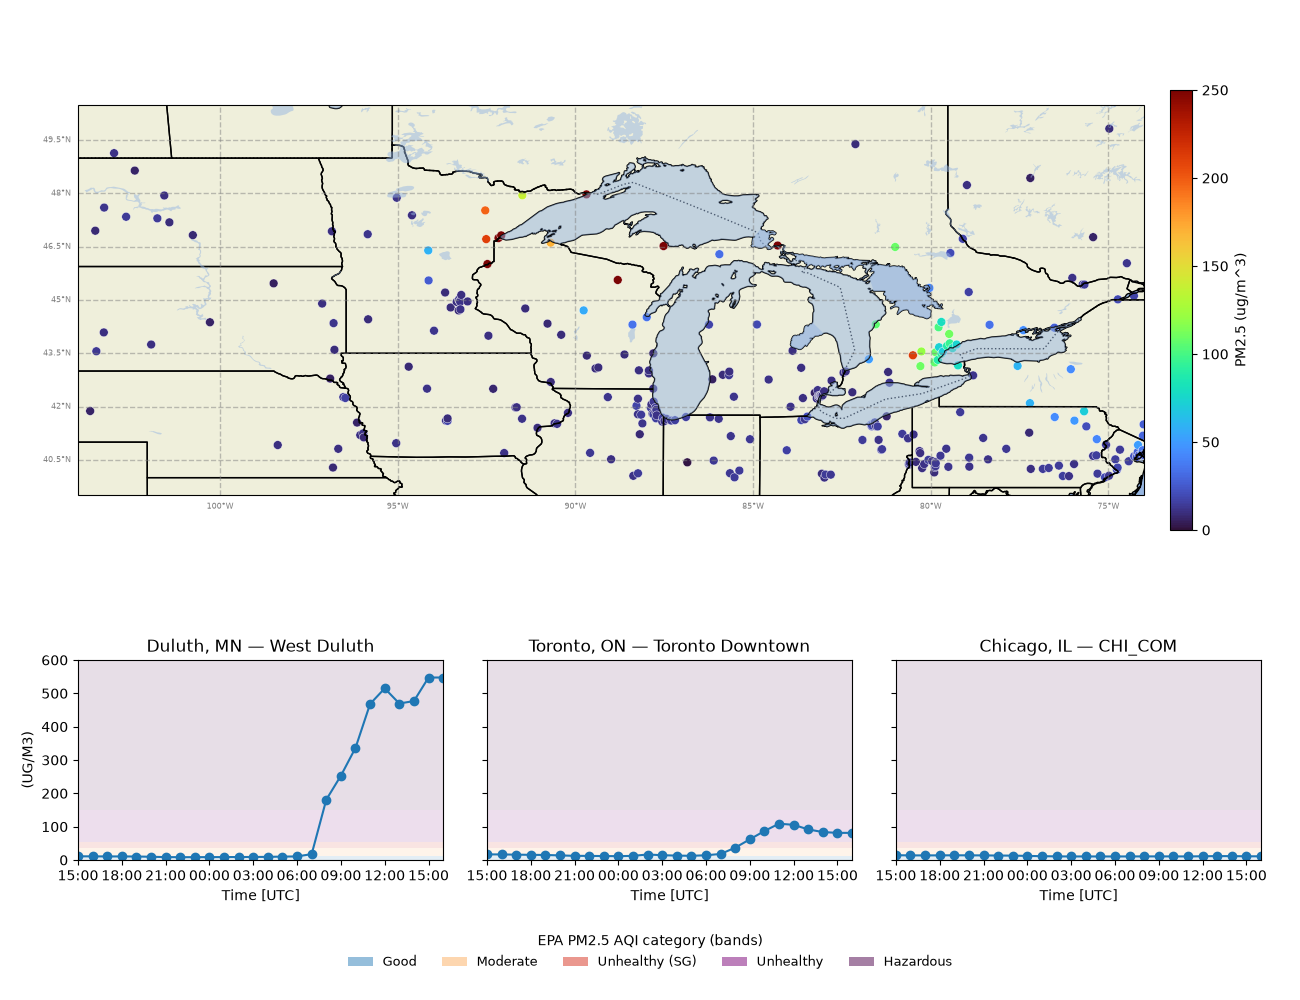

In [ ]:
geo = act.plotting.GeographicPlotDisplay(ds_latest)   # construct display first
plt.close("all")                                      # drop the stray figure the ctor created
fig = plt.figure(figsize=(13, 10))                    # our figure is now the current one

# --- top panel: regional station map ---
map_ax = geo.geoplot(
    "PM2.5", lat_field="latitude", lon_field="longitude",
    projection=ccrs.PlateCarree(),
    cartopy_feature=["LAND", "OCEAN", "LAKES", "STATES", "BORDERS"],
    title="US + Canada surface PM2.5 via AirNow (data pulled with ACT)",
    cmap="turbo", vmin=0, vmax=PM25_MAX,
    marker="o", s=40, edgecolor="white", linewidth=0.3,
)
map_ax.set_extent([-104, -74, 39.5, 50.5], crs=ccrs.PlateCarree())

# geoplot added [GeoAxes, colorbar]; move both into the top band.
cbar_ax = [a for a in fig.axes if a is not map_ax][0]
map_ax.set_position([0.06, 0.44, 0.82, 0.52])
cbar_ax.set_position([0.90, 0.47, 0.018, 0.44])

# --- bottom panels: three shared-y time series with EPA category bands ---
gs = fig.add_gridspec(1, 3, left=0.06, right=0.97, bottom=0.14, top=0.34, wspace=0.12)
bottom_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

tsd = act.plotting.TimeSeriesDisplay(ds_cities, subplot_shape=(1, 3))
plt.close(tsd.fig)          # discard the throwaway figure the display created
tsd.fig = fig               # point it at our figure and axes
tsd.axes = np.array([bottom_axes])
for idx, (city, (_, site)) in enumerate(cities.items()):
    ax = bottom_axes[idx]
    for lo, hi, color, _ in EPA_BANDS:            # shaded AQI bands behind the line
        ax.axhspan(lo, hi, color=color, alpha=0.13, zorder=0, linewidth=0)
    tsd.plot(
        "PM2.5", dsname=city, subplot_index=(0, idx),
        y_rng=(0, 600), force_line_plot=True, marker="o",
        set_title=f"{city} \u2014 {site}",
    )
    if idx > 0:                                   # label the y-axis once
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

# shared legend for the bands, on its own row at the bottom
handles = [Patch(facecolor=c, alpha=0.5, label=lbl) for _, _, c, lbl in EPA_BANDS]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 0.02), title="EPA PM2.5 AQI category (bands)")

plt.show()

## Summary

Using only `act.discovery.get_airnow_bounded_obs` for data access and ACT's `GeographicPlotDisplay` / `TimeSeriesDisplay` for visualization, one four-panel figure captures the cross-border smoke episode: PM$_{2.5}$ near Duluth reaching hazardous levels overnight, elevated values reaching into southern Ontario, and Chicago staying comparatively clean. The EPA category bands make the severity legible at a glance. The same pattern generalizes to any AirNow-covered region and date in the archive — change `map_bounds`, the city bounding boxes, and the date window.